# Sliding window Deep Neural Network

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [198]:
# Get the data ready
# Define the base directory containing all subfolders
base_dir = r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts"

# Initialize an empty DataFrame to store all data
all_data = pd.DataFrame()

# Iterate through all subfolders
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path):  # Check if it's a folder
        for file in os.listdir(folder_path):
            if file.endswith("_processed.csv"):  # Only process files ending with "_processed.csv"
                file_path = os.path.join(folder_path, file)
                print(f"Reading file: {file_path}")
                
                # Read the CSV file and append it to the DataFrame
                df = pd.read_csv(file_path)
                all_data = pd.concat([all_data, df], ignore_index=True)

# Save the concatenated DataFrame to a new CSV file
output_file = os.path.join(base_dir, "CAISO_LMP_Forecast_2022_07_to_2025_09.csv")
all_data.to_csv(output_file, index=False)
print(f"✅ All files concatenated and saved to: {output_file}")

Reading file: C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_07\CAISO_LMP_Forecast_2022_07_processed.csv
Reading file: C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_08\CAISO_LMP_Forecast_2022_08_processed.csv
Reading file: C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_09\CAISO_LMP_Forecast_2022_09_processed.csv
Reading file: C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_10\CAISO_LMP_Forecast_2022_10_processed.csv
Reading file: C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data\CAI

In [199]:
# Define rolling window length
t=100

# 1. Data Preparation

In [200]:
df=pd.read_csv(r"data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_07_to_2025_09.csv")


In [201]:
# Create a sliding window of size t for the LMP column
def create_sliding_window(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data['LMP'].iloc[i:i + window_size].values)
        y.append(data['LMP'].iloc[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sliding_window(df, t)
y = y.reshape(-1, 1)  # make y shape (27476, 1)
print(f"Sliding windows created: X shape = {X.shape}, y shape = {y.shape}")

Sliding windows created: X shape = (27476, 100), y shape = (27476, 1)


# 2. Train/Dev split

Performs a train/dev split based on time, the model will train from 2022_07_01+t to 2024_12_31 and be tested on all days between 2025_01 and 2025_09

In [202]:
#Performs a train/dev split based on time, the model will train from 2022_07_01+t to 2024_12_31 and be tested on all days between 2025_01 and 2025_09
train_end_year = 2024
train_end_month = 12
train_end_day = 31
train_end_hour = 24

# find the dataframe row index for the train end timestamp (columns: Year, Month, Date, Hour)
mask = (
    (df['Year'] == train_end_year) &
    (df['Month'] == train_end_month) &
    (df['Day'] == train_end_day) &
    (df['Hour'] == train_end_hour)
)
if not mask.any():
    raise ValueError(f"No row found for train end {train_end_year}-{train_end_month:02d}-{train_end_date:02d} hour {train_end_hour}")

end_row_idx = int(df.index[mask][0])

# For sliding windows: y[k] corresponds to df index k + t.
# We want all y where k + t <= end_row_idx -> k <= end_row_idx - t.
# Number of training samples = end_row_idx - t + 1
train_end_index = int(end_row_idx - t + 1)
if train_end_index < 0:
    raise ValueError("train_end_index < 0; increase data or reduce window size t")
X_train, y_train = X[:train_end_index], y[:train_end_index]
X_dev, y_dev = X[train_end_index:], y[train_end_index:]
print(f"Train/Dev split done: X_train shape = {X_train.shape}, y_train shape = {y_train.shape}, X_dev shape = {X_dev.shape}, y_dev shape = {y_dev.shape}")


Train/Dev split done: X_train shape = (21141, 100), y_train shape = (21141, 1), X_dev shape = (6335, 100), y_dev shape = (6335, 1)


# 3. Model Design

## a) Initialization

In [203]:

def initialize_parameters_deep(layer_dims):
    """
    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network
    
    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
    """
    
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) # number of layers in the network

    for l in range(1, L):

        parameters['W'+str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])*np.sqrt(2 / layer_dims[l-1])
        parameters['b'+str(l)]=np.zeros((layer_dims[l],1))
        
        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l - 1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

        
    return parameters

In [204]:
print("Test Case 1:\n")
parameters = initialize_parameters_deep([5,4,3])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
parameters

Test Case 1:

W1 = [[ 1.13122797  0.27607307  0.06103036 -1.17857627 -0.1754357 ]
 [-0.22436928 -0.05233031 -0.39655005 -0.02771304 -0.30181918]
 [-0.83096103  0.55948432  0.55739447  1.08122894  0.03164405]
 [-0.25594047 -0.34491592 -0.97807813  0.62130372 -0.69637631]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.83795444 -0.14541644  1.05086558  0.16738368]
 [-0.72392541 -0.50416233  0.44211496 -0.11350009]
 [-0.5436494  -0.16265628  0.52683434  1.39732134]]
b2 = [[0.]
 [0.]
 [0.]]


{'W1': array([[ 1.13122797,  0.27607307,  0.06103036, -1.17857627, -0.1754357 ],
        [-0.22436928, -0.05233031, -0.39655005, -0.02771304, -0.30181918],
        [-0.83096103,  0.55948432,  0.55739447,  1.08122894,  0.03164405],
        [-0.25594047, -0.34491592, -0.97807813,  0.62130372, -0.69637631]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.]]),
 'W2': array([[-0.83795444, -0.14541644,  1.05086558,  0.16738368],
        [-0.72392541, -0.50416233,  0.44211496, -0.11350009],
        [-0.5436494 , -0.16265628,  0.52683434,  1.39732134]]),
 'b2': array([[0.],
        [0.],
        [0.]])}

In [205]:
#Activation functions
def sigmoid(Z):
    """
    Implements the sigmoid activation in numpy
    
    Arguments:
    Z -- numpy array of any shape
    
    Returns:
    A -- output of sigmoid(z), same shape as Z
    cache -- returns Z as well, useful during backpropagation
    """
    
    A = 1/(1+np.exp(-Z))
    cache = Z
    
    return A, cache

def relu(Z):
    """
    Implement the RELU function.

    Arguments:
    Z -- Output of the linear layer, of any shape

    Returns:
    A -- Post-activation parameter, of the same shape as Z
    cache -- a python dictionary containing "A" ; stored for computing the backward pass efficiently
    """
    
    A = np.maximum(0,Z)
    
    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache


def relu_backward(dA, cache):
    """
    Implement the backward propagation for a single RELU unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
    
    Z = cache
    dZ = np.array(dA, copy=True) # just converting dz to a correct object.
    
    # When z <= 0, you should set dz to 0 as well. 
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

def sigmoid_backward(dA, cache):
    """
    Implement the backward propagation for a single SIGMOID unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
    
    Z = cache
    
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    
    assert (dZ.shape == Z.shape)
    
    return dZ

## b) Linear activation forward

In [206]:


def linear_forward(A, W, b):
    """
    Implement the linear part of a layer's forward propagation.

    Arguments:
    A -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)

    Returns:
    Z -- the input of the activation function, also called pre-activation parameter 
    cache -- a python tuple containing "A", "W" and "b" ; stored for computing the backward pass efficiently
    """
    Z=np.dot(W,A)+b
    

    cache = (A, W, b)
    
    return Z, cache

def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer

    Arguments:
    A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

    Returns:
    A -- the output of the activation function, also called the post-activation value 
    cache -- a python tuple containing "linear_cache" and "activation_cache";
             stored for computing the backward pass efficiently
    """
    
    if activation == "sigmoid":

        Z,linear_cache=linear_forward(A_prev,W,b)
        A,activation_cache=sigmoid(Z)
        
    
    elif activation == "relu":

        Z,linear_cache=linear_forward(A_prev,W,b)
        A,activation_cache=relu(Z)
        
    cache = (linear_cache, activation_cache)

    return A, cache

def L_model_forward(X, parameters):
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->RELU computation
    
    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()
    
    Returns:
    AL -- activation value from the output (last) layer
    caches -- list of caches containing:
                every cache of linear_activation_forward() (there are L of them, indexed from 0 to L-1)
    """

    caches = []
    A = X
    L = len(parameters) // 2                  # number of layers in the neural network
    for l in range(1, L):
        A_prev = A 

        A,cache=linear_activation_forward(A_prev,parameters["W"+str(l)],parameters["b"+str(l)],'relu')
        caches.append(cache)

    AL,cache=linear_activation_forward(A,parameters["W"+str(L)],parameters["b"+str(L)],'relu')
    caches.append(cache)

          
    return AL, caches

## c) Cost Function

The following cost function for our model is the Mean Squared Error: \
$
MSE = \frac{1}{m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2
$

Where:

( m ): Number of training examples.\
( $y_i$ ): True value (actual target) for the ( i )-th example.\
( $\hat{y}_i$): Predicted value for the ( i )-th example.

In [207]:
def compute_cost(AL, Y):
    """
    Implement the cost function defined by equation (7).

    Arguments:
    AL -- vector corresponding to your label predictions
    Y -- true "label" vector

    Returns:
    cost -- cross-entropy cost
    """
    
    m = Y.shape[1]

    cost=np.sum((AL-Y)**2)/m
    
    # YOUR CODE ENDS HERE
    
    cost = np.squeeze(cost)      # To make sure your cost's shape is what we expect (e.g. this turns [[17]] into 17).

    
    return cost

## d) Backward propagation

In [208]:
def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    A_prev, W, b = cache
    m = A_prev.shape[1]


    dW=np.dot(dZ,A_prev.T)/m
    db=np.sum(dZ,axis=1,keepdims=True)/m
    dA_prev=np.dot(W.T,dZ)

    
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation):
    """
    Implement the backward propagation for the LINEAR->ACTIVATION layer.
    
    Arguments:
    dA -- post-activation gradient for current layer l 
    cache -- tuple of values (linear_cache, activation_cache) we store for computing backward propagation efficiently
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"
    
    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    linear_cache, activation_cache = cache
    
    if activation == "relu":
        #(≈ 2 lines of code)
        # dZ =  ...
        # dA_prev, dW, db =  ...
        # YOUR CODE STARTS HERE
        dZ=relu_backward(dA,activation_cache)
        dA_prev,dW,db=linear_backward(dZ,linear_cache)
        # YOUR CODE ENDS HERE

    
    return dA_prev, dW, db

def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the [LINEAR->RELU] * (L-1) -> LINEAR -> SIGMOID group
    
    Arguments:
    AL -- probability vector, output of the forward propagation (L_model_forward())
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat)
    caches -- list of caches containing:
                every cache of linear_activation_forward() with "relu" (it's caches[l], for l in range(L-1) i.e l = 0...L-2)
                the cache of linear_activation_forward() with "relu" (it's caches[L-1])
    
    Returns:
    grads -- A dictionary with the gradients
             grads["dA" + str(l)] = ... 
             grads["dW" + str(l)] = ...
             grads["db" + str(l)] = ... 
    """
    grads = {}
    L = len(caches) # the number of layers
    m = AL.shape[1]
    Y = Y.reshape(AL.shape) # after this line, Y is the same shape as AL

    dAL = 2*(AL - Y)/m
    
    current_cache = caches[L-1]
    dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dAL,current_cache,"relu")
    grads["dA" + str(L-1)] = dA_prev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp
    

    for l in reversed(range(L-1)):

        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA"+str(l+1)],current_cache,"relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l+1)] = dW_temp
        grads["db" + str(l+1)] = db_temp


    return grads

In [209]:
def initialize_adam(parameters):
    """
    Initializes v and s as two dictionaries with the same keys as parameters' gradients.
    """
    L = len(parameters) // 2
    v = {}
    s = {}
    for l in range(1, L+1):
        v["dW" + str(l)] = np.zeros_like(parameters["W" + str(l)])
        v["db" + str(l)] = np.zeros_like(parameters["b" + str(l)])
        s["dW" + str(l)] = np.zeros_like(parameters["W" + str(l)])
        s["db" + str(l)] = np.zeros_like(parameters["b" + str(l)])
    return v, s

def update_parameters(params, grads, learning_rate, timestep, v, s,
                      beta1=0.9, beta2=0.999, epsilon=1e-8):
    """
    Update parameters using Adam.

    Arguments:
    params -- python dictionary containing your parameters (W1, b1, ..., WL, bL)
    grads -- python dictionary containing your gradients (dW1, db1, ..., dWL, dbL)
    learning_rate -- learning rate
    v -- moving average of the gradients (dict), if None it will be initialized
    s -- moving average of the squared gradients (dict), if None it will be initialized
    timestep -- timestep (int, should start at 1 and be incremented each update call)
    beta1, beta2, epsilon -- Adam hyperparameters

    Returns:
    parameters -- updated parameters dictionary
    v, s -- updated Adam moment dictionaries
    """
    # make a copy of parameters to avoid mutating the original dict's references
    parameters = {k: np.copy(vv) for k, vv in params.items()}
    L = len(parameters) // 2
    for l in range(1, L+1):
        # update moving averages of the gradients
        v["dW" + str(l)] = beta1 * v["dW" + str(l)] + (1 - beta1) * grads["dW" + str(l)]
        v["db" + str(l)] = beta1 * v["db" + str(l)] + (1 - beta1) * grads["db" + str(l)]

        # update moving averages of the squared gradients
        s["dW" + str(l)] = beta2 * s["dW" + str(l)] + (1 - beta2) * (grads["dW" + str(l)] ** 2)
        s["db" + str(l)] = beta2 * s["db" + str(l)] + (1 - beta2) * (grads["db" + str(l)] ** 2)

        # compute bias-corrected estimates
        v_corrected_dW = v["dW" + str(l)] / (1 - beta1 ** timestep)
        v_corrected_db = v["db" + str(l)] / (1 - beta1 ** timestep)
        s_corrected_dW = s["dW" + str(l)] / (1 - beta2 ** timestep)
        s_corrected_db = s["db" + str(l)] / (1 - beta2 ** timestep)

        # update parameters
        parameters["W" + str(l)] -= learning_rate * v_corrected_dW / (np.sqrt(s_corrected_dW) + epsilon)
        parameters["b" + str(l)] -= learning_rate * v_corrected_db / (np.sqrt(s_corrected_db) + epsilon)

    return parameters, v, s

# 4. Model Training

In [210]:
layer_dims = [t, 64, 32, 16, 1]  # Example layer dimensions


In [211]:
def model(X, Y, layers_dims, learning_rate, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->RELU.
    
    Arguments:
    X -- input data, of shape (t, number of examples)
    Y -- true "label" vector (of shape (1, number of examples))
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    np.random.seed(1)
    costs = []                         # keep track of cost
    timestep=0
    # Parameters initialization.

    parameters=initialize_parameters_deep(layers_dims)
    v,s=initialize_adam(parameters)
    
    # Loop (adam update)
    for i in range(0, num_iterations):
        timestep += 1
        AL,caches=L_model_forward(X,parameters)
        cost=compute_cost(AL,Y)
        grads=L_model_backward(AL,Y,caches)
        parameters,v,s=update_parameters(parameters,grads,learning_rate,timestep,v,s)
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

In [212]:
X_train=X_train.T  # shape (t, number of training examples)
y_train=y_train.T  # shape (1, number of training examples)
y_dev=y_dev.T      # shape (1, number of dev examples)
X_dev=X_dev.T  # shape (t, number of dev examples)
print(f"X_train shape after transpose: {X_train.shape}, y_train shape after transpose: {y_train.shape}")


X_train shape after transpose: (100, 21141), y_train shape after transpose: (1, 21141)


In [213]:
parameters, costs = model(X_train, y_train, layer_dims, learning_rate=0.001, num_iterations=3000, print_cost=True)

Cost after iteration 0: 5601.972226182259
Cost after iteration 100: 259.93927437795224
Cost after iteration 200: 135.39079910254156
Cost after iteration 300: 106.52392299560819
Cost after iteration 400: 92.52981717304516
Cost after iteration 500: 84.20836116961301
Cost after iteration 600: 76.3313695053432
Cost after iteration 700: 73.10506341053834
Cost after iteration 800: 68.09321425556124
Cost after iteration 900: 64.2507325647787
Cost after iteration 1000: 62.42855159650531
Cost after iteration 1100: 58.52099846684456
Cost after iteration 1200: 56.3231146062483
Cost after iteration 1300: 53.95884438856424
Cost after iteration 1400: 52.418795117265795
Cost after iteration 1500: 50.885221828006934
Cost after iteration 1600: 49.386184010546465
Cost after iteration 1700: 48.859874645035994
Cost after iteration 1800: 49.04167248407632
Cost after iteration 1900: 46.46232379933166
Cost after iteration 2000: 46.286186953322634
Cost after iteration 2100: 46.671492686095746
Cost after itera

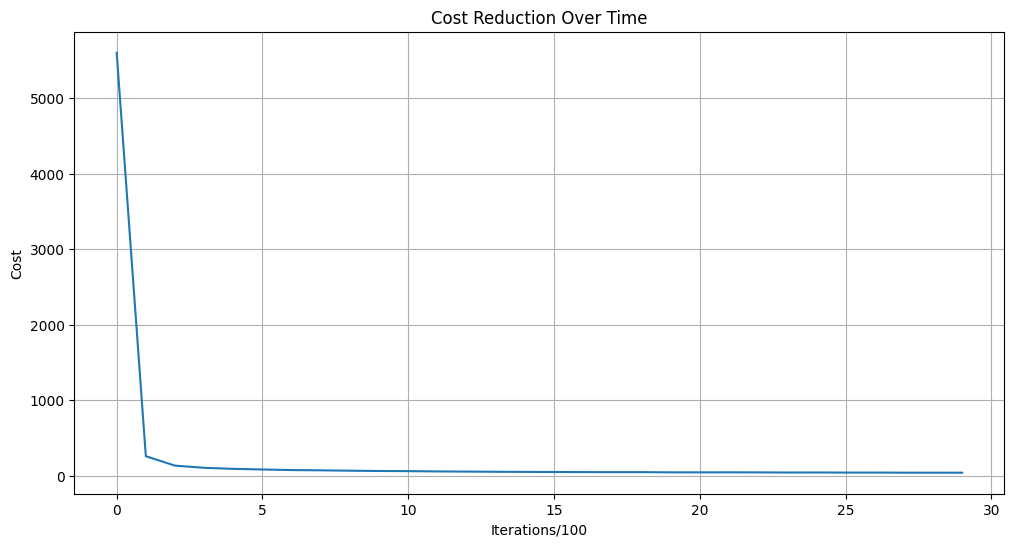

In [214]:
plt.figure(figsize=(12, 6))
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations/100')
plt.title('Cost Reduction Over Time')
plt.grid()
plt.show()

In [215]:
def predict(X, Y, parameters):
    """
    Predicts the output for a given input X using the trained parameters and computes the rMAE.

    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector (of shape (1, number of examples))
    parameters -- parameters of the trained model

    Returns:
    rMAE -- relative Mean Absolute Error
    """
    # Forward propagation to get predictions
    AL, _ = L_model_forward(X, parameters)  # AL is the predicted output

    # Compute the naive baseline (e.g., price from 7 days earlier)
    # Assuming Y is ordered by time, and the naive baseline is Y shifted by 7 days
    naive_baseline = np.roll(Y, shift=-24*7, axis=1)  # Shift by 7 days (24 hours/day)
    naive_baseline[:, -24*7:] = Y[:, -24*7:]  # Handle edge cases by copying the last valid values

    # Compute the Mean Absolute Error (MAE) for predictions
    mae_model = np.mean(np.abs(AL - Y))

    # Compute the MAE for the naive baseline
    mae_naive = np.mean(np.abs(naive_baseline - Y))

    # Compute the relative Mean Absolute Error (rMAE)
    rMAE = mae_model / mae_naive

    print(f"rMAE: {rMAE}")
    print(f"MAE Model: {mae_model}, MAE Naive: {mae_naive}")
    print(f"Accuracy (1 - rMAE): {1 - rMAE}")
    return AL, rMAE

In [216]:
predictions_train, rmae_train=predict(X_train, y_train, parameters)

rMAE: 0.18219232006676445
MAE Model: 3.788183677987417, MAE Naive: 20.79222481276508
Accuracy (1 - rMAE): 0.8178076799332356


rMAE: 0.3529015435122722
MAE Model: 3.165499289831548, MAE Naive: 8.969921917390161
Accuracy (1 - rMAE): 0.6470984564877278


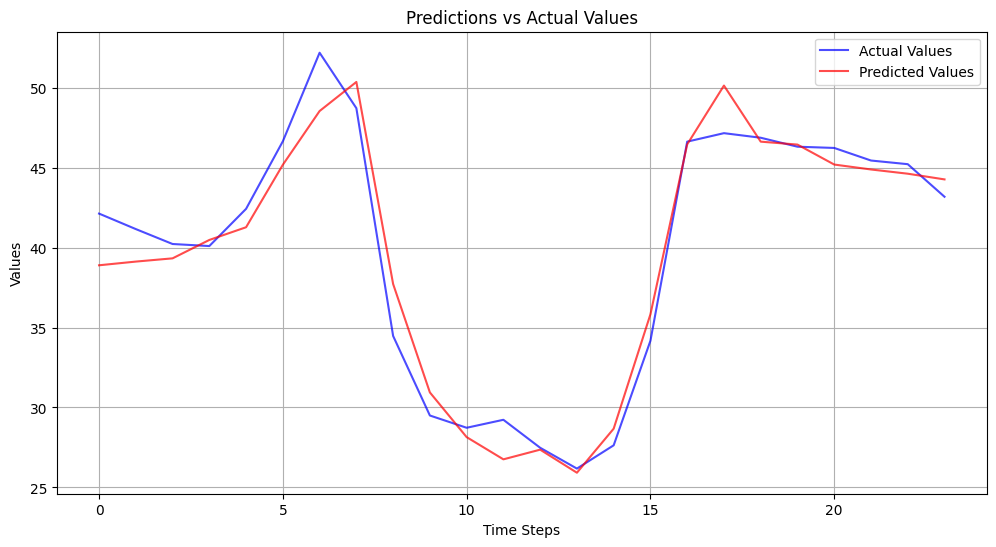

In [217]:
# Get predictions and rMAE for the test set
predictions_test, rmae_test = predict(X_dev, y_dev, parameters)

# Plot predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_dev.flatten()[24:48], label="Actual Values", color="blue", alpha=0.7)
plt.plot(predictions_test.flatten()[24:48], label="Predicted Values", color="red", alpha=0.7)
plt.title("Predictions vs Actual Values")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.grid()
plt.show()